# Hearthstone Deck Builder — Deep Neural Network

Class-conditioned causal Transformer that generates 30-card Hearthstone decks.

1. Downloads `CardDefs.xml` (HearthDb's own source — HearthstoneJSON's mirror).
2. Loads **real meta decks** from deckstrings (HearthSim's `hearthstone` package decodes them).
3. Augments with synthetic legal decks for breadth.
4. Trains a Transformer over card-ID tokens, conditioned on hero class.
5. Autoregressively samples new decks with a legality mask.

**Tip:** enable GPU via `Runtime → Change runtime type → GPU` for ~10x faster training.

## 1. Environment check

In [ ]:
import torch
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Install dependencies

`hearthstone` is HearthSim's official Python package — it decodes deckstrings into (DBF ID, count) tuples.

In [ ]:
!pip install --quiet hearthstone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 3.0 MB/s eta 0:00:00


## 3. Imports and constants

In [ ]:
from __future__ import annotations

import os
import random
import urllib.request
import xml.etree.ElementTree as ET
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from hearthstone.deckstrings import Deck

CARDDEFS_URL = "https://raw.githubusercontent.com/HearthSim/hsdata/master/CardDefs.xml"
CACHE_PATH = "/content/CardDefs.xml" if os.path.isdir("/content") else "CardDefs.xml"

DECK_SIZE = 30
PAD, SOS, EOS = "<PAD>", "<SOS>", "<EOS>"

# GameTag enum IDs in CardDefs.xml
TAG_CARDNAME = 185
TAG_COST = 48
TAG_CLASS = 199
TAG_CARDTYPE = 202
TAG_RARITY = 203
TAG_COLLECTIBLE = 321

CARDTYPE_HERO = 3

CLASS_MAP = {
    1: "DEATHKNIGHT",
    2: "DRUID",
    3: "HUNTER",
    4: "MAGE",
    5: "PALADIN",
    6: "PRIEST",
    7: "ROGUE",
    8: "SHAMAN",
    9: "WARLOCK",
    10: "WARRIOR",
    14: "DEMONHUNTER"
}
CARDTYPE_MAP = {3: "HERO", 4: "MINION", 5: "SPELL", 7: "WEAPON", 39: "LOCATION"}
RARITY_MAP = {1: "COMMON", 2: "FREE", 3: "RARE", 4: "EPIC", 5: "LEGENDARY"}

HERO_CLASSES = ("DEATHKNIGHT", "DEMONHUNTER", "DRUID", "HUNTER", "MAGE", "PALADIN", "PRIEST", "ROGUE", "SHAMAN", "WARLOCK", "WARRIOR")

print(HERO_CLASSES)
torch.manual_seed(0)
random.seed(0)

('DEATHKNIGHT', 'DEMONHUNTER', 'DRUID', 'HUNTER', 'MAGE', 'PALADIN', 'PRIEST', 'ROGUE', 'SHAMAN', 'WARLOCK', 'WARRIOR')


## 4. Fetch and parse the card database

Also extracts:
- **DBF ID** (`Entity ID` attribute) — needed to map deckstring entries to cards.
- **Hero entities** — needed to map a deckstring's hero portrait to a class name.

In [ ]:
@dataclass
class Card:
    card_id: str
    dbf_id: int
    name: str
    cost: int
    card_class: str
    card_type: str
    rarity: str


def fetch_card_defs() -> str:
    # if os.path.exists(CACHE_PATH):
    #     with open(CACHE_PATH, "r", encoding="utf-8") as f:
    #         return f.read()
    print(f"Downloading {CARDDEFS_URL}")
    req = urllib.request.Request(
        CARDDEFS_URL, headers={"User-Agent": "hearthstone-deck-builder"}
    )
    with urllib.request.urlopen(req, timeout=120) as resp:
        text = resp.read().decode("utf-8")
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        f.write(text)
    return text


def _tag_int(tag) -> int:
    try:
        return int(tag.attrib.get("value", "0"))
    except ValueError:
        return 0


def parse_cards(xml_text: str):
    """Return (playable_cards, dbf_to_cardid, dbf_to_name, hero_dbf_to_class)."""
    root = ET.fromstring(xml_text)
    cards: List[Card] = []
    dbf_to_cardid: Dict[int, str] = {}
    dbf_to_name: Dict[int, str] = {}
    hero_dbf_to_class: Dict[int, str] = {}

    for entity in root.findall("Entity"):
        card_id = entity.attrib.get("CardID", "")
        try:
            dbf_id = int(entity.attrib.get("ID", "0"))
        except ValueError:
            dbf_id = 0
        name, cost = "", 0
        card_class, card_type, rarity = "NEUTRAL", "", ""
        collectible = False
        for tag in entity.findall("Tag"):
            try:
                eid = int(tag.attrib.get("enumID", "0"))
            except ValueError:
                continue
            if eid == TAG_CARDNAME:
                child = tag.find("enUS")
                if child is not None and child.text:
                    name = child.text
            elif eid == TAG_COST:
                cost = _tag_int(tag)
            elif eid == TAG_CLASS:
                card_class = CLASS_MAP.get(_tag_int(tag), "NEUTRAL")
            elif eid == TAG_CARDTYPE:
                card_type = CARDTYPE_MAP.get(_tag_int(tag), "")
            elif eid == TAG_RARITY:
                rarity = RARITY_MAP.get(_tag_int(tag), "")
            elif eid == TAG_COLLECTIBLE:
                collectible = _tag_int(tag) == 1

        if dbf_id and card_id:
            dbf_to_cardid[dbf_id] = card_id
            dbf_to_name[dbf_id] = name or card_id
        if card_type == "HERO" and card_class in HERO_CLASSES:
            hero_dbf_to_class[dbf_id] = card_class

        if collectible and card_type in ("MINION", "SPELL", "WEAPON", "LOCATION", "HERO"):
            cards.append(
                Card(card_id, dbf_id, name or card_id, cost,
                     card_class, card_type, rarity)
            )
    return cards, dbf_to_cardid, dbf_to_name, hero_dbf_to_class


xml_text = fetch_card_defs()
cards, dbf_to_cardid, dbf_to_name, hero_dbf_to_class = parse_cards(xml_text)
collectible_dbfs = {c.dbf_id for c in cards}
print(f"Loaded {len(cards)} collectible playable cards")
print(f"Mapped {len(dbf_to_cardid)} DBF IDs total and {len(hero_dbf_to_class)} hero portraits")

from collections import Counter
print("Cards per class:", Counter(c.card_class for c in cards))

Loaded 7948 collectible playable cards
Mapped 35046 DBF IDs total and 1862 hero portraits
Cards per class: Counter({'NEUTRAL': 2097, 'MAGE': 583, 'PALADIN': 583, 'PRIEST': 580, 'DRUID': 579, 'WARLOCK': 574, 'HUNTER': 573, 'WARRIOR': 570, 'SHAMAN': 564, 'ROGUE': 561, 'DEMONHUNTER': 389, 'DEATHKNIGHT': 295})


## 5. Load real meta decks (deckstrings)

Paste deckstrings into the `DECKSTRINGS` list. Sources:

- **In-game** (most reliable, always current): Collection → pick a deck → click `Copy`.
- **HSReplay.net**, **HearthstoneTopDecks.com**, **Tempo Storm**, **Vicious Syndicate**: each deck page has a Copy/Export button.

A deckstring looks like `AAECAR8GhwTKA7sFn8IC...`. The loader checks each one against the current card pool — if a deck references a card that's been rotated out of `CardDefs.base.xml`, it prints which DBF IDs are missing so you can pick another deck or update your card data.

In [ ]:
DECKSTRINGS: List[str] = [
    "..."
]

# Optional: also load deckstrings from /content/decks.txt (one per line).
# DECKS_TXT = "/content/decks.txt"
# if os.path.exists(DECKS_TXT):
#     with open(DECKS_TXT) as f:
#         for line in f:
#             line = line.strip()
#             if line and not line.startswith("#"):
#                 DECKSTRINGS.append(line)

ONLY_COLLECTIBLE = False   # set False to also accept non-collectible / Wild-rotated cards


def deckstring_to_record(ds: str):
    """Decode a deckstring. Returns ((hero_class, [card_ids]), None) on success,
    or (None, reason_str) on failure with detailed diagnostics."""
    deck = Deck.from_deckstring(ds)
    if not deck.heroes:
        return None, "no hero in deckstring"
    hero_dbf = deck.heroes[0]
    hero_class = hero_dbf_to_class.get(hero_dbf)
    if hero_class not in HERO_CLASSES:
        return None, f"unrecognized hero DBF {hero_dbf}"

    card_ids: List[str] = []
    missing: List[Tuple[int, int]] = []
    non_collectible: List[Tuple[int, int, str]] = []
    for dbf_id, count in deck.cards:
        cid = dbf_to_cardid.get(dbf_id)
        if cid is None:
            missing.append((dbf_id, count))
            continue
        if ONLY_COLLECTIBLE and dbf_id not in collectible_dbfs:
            non_collectible.append((dbf_id, count, dbf_to_name.get(dbf_id, "?")))
            continue
        card_ids.extend([cid] * count)

    if missing:
        details = ", ".join(f"DBF {d}×{c}" for d, c in missing[:5])
        more = "" if len(missing) <= 5 else f" (+{len(missing) - 5} more)"
        return None, f"{sum(c for _, c in missing)} card(s) reference unknown DBF IDs: {details}{more}"
    if non_collectible:
        details = ", ".join(f"{n} (DBF {d}×{c})" for d, c, n in non_collectible[:5])
        return None, f"{len(non_collectible)} non-collectible card(s) — set ONLY_COLLECTIBLE=False to allow: {details}"
    if len(card_ids) != DECK_SIZE:
        return None, f"deck has {len(card_ids)} cards, expected {DECK_SIZE}"
    return (hero_class, card_ids), None


real_decks: List[Tuple[str, List[str]]] = []
if not DECKSTRINGS:
    print("No deckstrings provided — training will use synthetic decks only.")
    print("Paste deckstrings into DECKSTRINGS above (or upload /content/decks.txt) and re-run.")
else:
    for ds in DECKSTRINGS:
        short = ds[:30] + ("…" if len(ds) > 30 else "")
        try:
            rec, err = deckstring_to_record(ds)
        except Exception as e:
            print(f"  [decode error] {short}  →  {type(e).__name__}: {e}")
            continue
        if rec is None:
            print(f"  [skip]         {short}  →  {err}")
            continue
        hero, ids = rec
        real_decks.append(rec)
        print(f"  [ok]   {hero:<12}  {short}")

print(f"\nLoaded {len(real_decks)} real deck(s).")

  [ok]   DEMONHUNTER   AAECAea5Aw6coATh+AXHpAb6wAb8wA…
  [ok]   DEMONHUNTER   AAECAea5AwrHpAb8wAaq6gbO8QbB/g…
  [ok]   DEMONHUNTER   AAECAea5AwzHpAb6wAb8wAaq6gbB/g…
  [ok]   DEMONHUNTER   AAECAea5AwyongbHpAaq6gbh6wap9Q…
  [ok]   DEMONHUNTER   AAECAea5Awzj+AXDsAa9vgbfwAb8wA…
  [ok]   DEMONHUNTER   AAECAea5Awb8wAaq6gaDigeKqgeSqg…
  [ok]   DEMONHUNTER   AAECAea5AwbfwAb8wAaq6gaKqgeSqg…
  [ok]   DEMONHUNTER   AAECAea5Awrj+AXDsAa9vgbfwAb8wA…
  [ok]   DEMONHUNTER   AAECAea5AwrDsAbfwAb2wAb8wAaq6g…
  [ok]   DEMONHUNTER   AAECAea5Awa9vgb8wAaq6gaKqgeSqg…
  [ok]   PALADIN       AAECAZ8FDsmgBMekBs2pBrHBBuHrBv…
  [ok]   DEMONHUNTER   AAECAea5AwjDsAbfwAb2wAb8wAaq6g…
  [ok]   DEMONHUNTER   AAECAea5AwiXoASongb8wAbR/gaKqg…
  [ok]   DEMONHUNTER   AAECAea5AwiAhQTHpAb6wAb8wAaCmA…
  [ok]   DEMONHUNTER   AAECAea5AwaXoASongaKqgeSqgeTqg…
  [ok]   DEMONHUNTER   AAECAaarBAaXoASongaKqgeSqgeTqg…
  [ok]   PALADIN       AAECAZ8FDs2eBsekBs2pBrHBBuHrBv…
  [ok]   PALADIN       AAECAZ8FCsekBs2pBsnlBqXoBqrqBo…
  [ok]   P

##5.5 Data splitting

Splits the data into 70/15/15 split

In [ ]:
from collections import defaultdict
import random

# 1. Deduplicate first — same deck listed twice would leak across splits.
seen = set()
unique_real = []
for hero, ids in real_decks:
    key = (hero, tuple(sorted(ids)))
    if key in seen:
        continue
    seen.add(key)
    unique_real.append((hero, ids))
print(f"{len(unique_real)} unique real decks (from {len(real_decks)} total)")

# 2. Group by hero class so we can stratify.
by_hero = defaultdict(list)
for rec in unique_real:
    by_hero[rec[0]].append(rec)

# 3. Stratified split: 70% train, 15% val, 15% test per class.
split_rng = random.Random(42)
train_decks, val_decks, test_decks = [], [], []
for hero, decks in by_hero.items():
    split_rng.shuffle(decks)
    n = len(decks)
    n_test = max(1, int(round(n * 0.15))) if n >= 4 else 0
    n_val  = max(1, int(round(n * 0.15))) if n >= 4 else 0
    n_train = n - n_val - n_test
    train_decks += decks[:n_train]
    val_decks   += decks[n_train:n_train + n_val]
    test_decks  += decks[n_train + n_val:]
    print(f"  {hero:<12} total={n:>3}  train={n_train:>3}  val={n_val:>2}  test={n_test:>2}")

print(f"\nSplit sizes: train={len(train_decks)}  val={len(val_decks)}  test={len(test_decks)}")

567 unique real decks (from 567 total)
  DEMONHUNTER  total= 84  train= 58  val=13  test=13
  PALADIN      total= 47  train= 33  val= 7  test= 7
  DEATHKNIGHT  total= 77  train= 53  val=12  test=12
  WARRIOR      total= 43  train= 31  val= 6  test= 6
  SHAMAN       total= 20  train= 14  val= 3  test= 3
  DRUID        total= 39  train= 27  val= 6  test= 6
  HUNTER       total= 46  train= 32  val= 7  test= 7
  ROGUE        total= 84  train= 58  val=13  test=13
  MAGE         total= 74  train= 52  val=11  test=11
  WARLOCK      total= 13  train=  9  val= 2  test= 2
  PRIEST       total= 40  train= 28  val= 6  test= 6

Split sizes: train=395  val=86  test=86


## 6. Build the training dataset

Real decks, synthetic decks and the curve weights are set, currently there is only real decks and no synthetic dekcs.

In [ ]:
CURVE_WEIGHT = {0: 0.4, 1: 1.2, 2: 2.6, 3: 3.0, 4: 2.4,
                5: 1.8, 6: 1.3, 7: 0.9, 8: 0.5, 9: 0.3, 10: 0.2}

DECKS_PER_CLASS = 0
REAL_REPLICATION = 20


def synthesize_deck(pool: List[Card], rng: random.Random,
                    weights: Optional[List[float]] = None) -> List[str]:
    # Pre-compute weights once per pool (caller can pass cached weights).
    if weights is None:
        weights = [CURVE_WEIGHT.get(min(c.cost, 10), 0.1) for c in pool]
    deck: List[str] = []
    counts: Dict[str, int] = defaultdict(int)
    guard = 0
    while len(deck) < DECK_SIZE and guard < 10_000:
        guard += 1
        c = rng.choices(pool, weights=weights, k=1)[0]
        cap = 1 if c.rarity == "LEGENDARY" else 2
        if counts[c.card_id] >= cap:
            continue
        deck.append(c.card_id)
        counts[c.card_id] += 1
    return deck


class Vocab:
    def __init__(self, cards: List[Card]):
        self.itos = [PAD, SOS, EOS] + sorted({c.card_id for c in cards})
        self.stoi = {s: i for i, s in enumerate(self.itos)}
        self.pad_id = self.stoi[PAD]
        self.sos_id = self.stoi[SOS]
        self.eos_id = self.stoi[EOS]

    def __len__(self) -> int:
        return len(self.itos)


class DeckDataset(Dataset):
    def __init__(
        self,
        cards: List[Card],
        vocab: Vocab,
        decks_per_class: int = 400,
        real_decks: Optional[List[Tuple[str, List[str]]]] = None,
        real_replication: int = 1,
        seed: int = 0,
    ):
        rng = random.Random(seed)
        by_class: Dict[str, List[Card]] = defaultdict(list)
        for c in cards:
            by_class[c.card_class].append(c)
        neutrals = by_class.get("NEUTRAL", [])
        # HERO_CLASSES is now an ordered tuple, so enumerate is deterministic.
        self.class_to_id = {h: i for i, h in enumerate(HERO_CLASSES)}
        cost_lookup_all = {c.card_id: c.cost for c in cards}

        sos, eos = vocab.sos_id, vocab.eos_id
        # Pre-allocate tensors; every sequence is exactly DECK_SIZE + 2 tokens.
        seq_len = DECK_SIZE + 2
        self.samples: List[Tuple[int, "torch.Tensor"]] = []

        # Synthetic decks: broad coverage of the legal space.
        for hero in HERO_CLASSES:
            pool = by_class.get(hero, []) + neutrals
            if not pool:
                continue
            cls_id = self.class_to_id[hero]
            cost_lookup = {c.card_id: c.cost for c in pool}
            pool_weights = [CURVE_WEIGHT.get(min(c.cost, 10), 0.1) for c in pool]
            for _ in range(decks_per_class):
                deck = synthesize_deck(pool, rng, weights=pool_weights)
                deck.sort(key=lambda cid: cost_lookup[cid])
                ids = [sos] + [vocab.stoi[cid] for cid in deck] + [eos]
                self.samples.append((cls_id, torch.tensor(ids, dtype=torch.long)))

        # Real meta decks: heavily oversampled so they actually steer the model.
        # Share the same tensor across replications (no copy needed since Dataset is read-only).
        n_real = 0
        for hero, card_ids in (real_decks or []):
            cls_id = self.class_to_id[hero]
            ordered = sorted(card_ids, key=lambda cid: cost_lookup_all.get(cid, 0))
            ids = [sos] + [vocab.stoi[cid] for cid in ordered if cid in vocab.stoi] + [eos]
            if len(ids) != seq_len:
                continue
            tens = torch.tensor(ids, dtype=torch.long)
            for _ in range(real_replication):
                self.samples.append((cls_id, tens))
            n_real += 1
        self.n_real_unique = n_real

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate(batch, vocab: Vocab):
    # All sequences are pre-tokenized tensors of identical length — stack directly.
    cls_ids = torch.tensor([b[0] for b in batch], dtype=torch.long)
    seqs = torch.stack([b[1] for b in batch], dim=0)
    return cls_ids, seqs


vocab = Vocab(cards)
print(f"Vocab size: {len(vocab)}")

# Training set: synthetic + replicated train real decks (as before)
dataset = DeckDataset(
    cards, vocab,
    decks_per_class=DECKS_PER_CLASS,
    real_decks=train_decks,        # <-- only train split
    real_replication=REAL_REPLICATION,
)

# Validation set: just the held-out real decks, no synthetic, no replication.
val_dataset = DeckDataset(
    cards, vocab,
    decks_per_class=0,             # no synthetic
    real_decks=val_decks,
    real_replication=1,
)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True,
                          collate_fn=lambda b: collate(b, vocab),
                          num_workers=2, pin_memory=(DEVICE == "cuda"),
                          persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        collate_fn=lambda b: collate(b, vocab),
                        pin_memory=(DEVICE == "cuda"))
n_synth = len(dataset) - dataset.n_real_unique * REAL_REPLICATION
print(
    f"Training samples: {len(dataset):,} "
    f"({n_synth:,} synthetic + {dataset.n_real_unique} unique real ×{REAL_REPLICATION})"
)
print(f"Validation samples: {len(val_dataset):,}")

Vocab size: 7951
Training samples: 6,000 (0 synthetic + 300 unique real ×20)
Validation samples: 67


## 7. Define the Transformer model

Hyperparameters set

In [ ]:
class DeckTransformer(nn.Module):
    """Class-conditioned causal Transformer over card tokens."""

    def __init__(
        self,
        vocab_size: int,
        n_classes: int,
        d_model: int = 192,
        nhead: int = 6,
        n_layers: int = 4,
        max_len: int = DECK_SIZE + 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.cls_emb = nn.Embedding(n_classes, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len
        # Cache the causal mask once as a non-trainable buffer; sliced per forward.
        causal = nn.Transformer.generate_square_subsequent_mask(max_len)
        self.register_buffer("causal_mask", causal, persistent=False)
        # Cache positions [0..max_len) once.
        self.register_buffer("pos_ids", torch.arange(max_len).unsqueeze(0), persistent=False)

    def forward(self, tokens, hero_cls):
        B, T = tokens.shape
        pos = self.pos_ids[:, :T].expand(B, T)
        h = (
            self.tok_emb(tokens)
            + self.pos_emb(pos)
            + self.cls_emb(hero_cls).unsqueeze(1)
        )
        causal = self.causal_mask[:T, :T]
        h = self.encoder(h, mask=causal, is_causal=True)
        return self.head(self.norm(h))


model = DeckTransformer(vocab_size=len(vocab), n_classes=len(HERO_CLASSES)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model on {DEVICE} — {n_params:,} parameters")

Model on cuda — 4,849,615 parameters


## 8. Train

Set Epoch and learning rate

epoch 1/25  train=5.5131  val=4.3615  best_val=4.3615
epoch 2/25  train=2.2799  val=3.1536  best_val=3.1536
epoch 3/25  train=1.1963  val=2.7783  best_val=2.7783
epoch 4/25  train=0.6718  val=2.6658  best_val=2.6658
epoch 5/25  train=0.4094  val=2.6707  best_val=2.6658
epoch 6/25  train=0.2876  val=2.7186  best_val=2.6658
epoch 7/25  train=0.2307  val=2.7452  best_val=2.6658
epoch 8/25  train=0.1994  val=2.7864  best_val=2.6658
epoch 9/25  train=0.1809  val=2.8126  best_val=2.6658
epoch 10/25  train=0.1697  val=2.8521  best_val=2.6658
epoch 11/25  train=0.1614  val=2.8716  best_val=2.6658
epoch 12/25  train=0.1553  val=2.8914  best_val=2.6658
epoch 13/25  train=0.1516  val=2.8982  best_val=2.6658
epoch 14/25  train=0.1484  val=2.9220  best_val=2.6658
epoch 15/25  train=0.1447  val=2.9340  best_val=2.6658
epoch 16/25  train=0.1427  val=2.9486  best_val=2.6658
epoch 17/25  train=0.1405  val=2.9560  best_val=2.6658
epoch 18/25  train=0.1387  val=2.9636  best_val=2.6658
epoch 19/25  train=

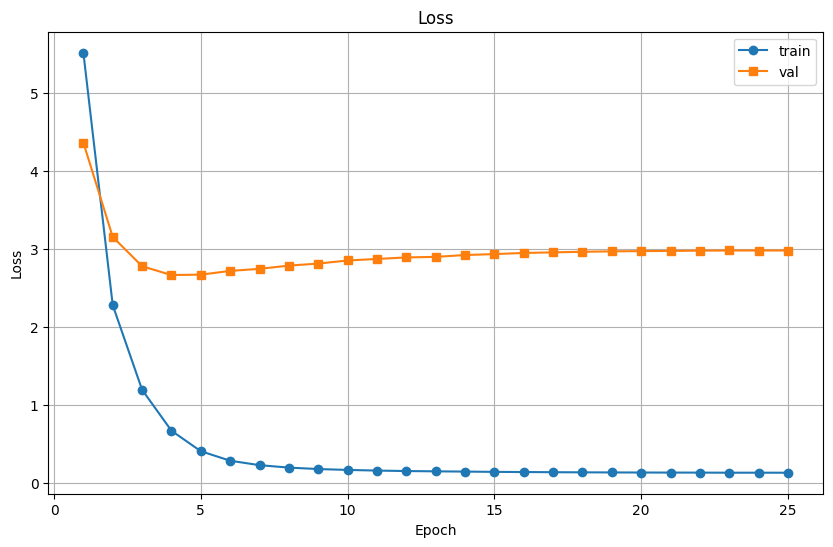

In [ ]:
EPOCHS = 25
LR = 3e-4

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * len(train_loader))

# Use AMP autocast on CUDA (fp16) or CPU (bfloat16) where supported.
AMP_DTYPE = torch.float16 if DEVICE == "cuda" else torch.bfloat16
AMP_ENABLED = (DEVICE == "cuda")  # CPU autocast available but often slower; keep off by default.

model.train()
@torch.no_grad()
def eval_loss(loader):
    model.eval()
    total, n = 0.0, 0
    for cls_ids, seqs in loader:
        cls_ids = cls_ids.to(DEVICE, non_blocking=True)
        seqs = seqs.to(DEVICE, non_blocking=True)
        inp, tgt = seqs[:, :-1], seqs[:, 1:]
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=AMP_ENABLED):
            logits = model(inp, cls_ids)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                tgt.reshape(-1),
                ignore_index=vocab.pad_id,
            )
        total += loss.item() * seqs.size(0)
        n += seqs.size(0)
    model.train()
    return total / max(n, 1)

train_losses, val_losses = [], []
best_val, best_state = float("inf"), None

for ep in range(EPOCHS):
    running = 0.0
    for cls_ids, seqs in train_loader:
        cls_ids = cls_ids.to(DEVICE, non_blocking=True)
        seqs = seqs.to(DEVICE, non_blocking=True)
        inp, tgt = seqs[:, :-1], seqs[:, 1:]
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=AMP_ENABLED):
            logits = model(inp, cls_ids)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                tgt.reshape(-1),
                ignore_index=vocab.pad_id,
            )
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        running += loss.item()
    tr = running / len(train_loader)
    va = eval_loss(val_loader)
    train_losses.append(tr); val_losses.append(va)
    if va < best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch {ep+1}/{EPOCHS}  train={tr:.4f}  val={va:.4f}  best_val={best_val:.4f}")

# Restore best checkpoint by validation loss (simple early-stopping equivalent).
model.load_state_dict(best_state)

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), train_losses, label="train", marker='o')
plt.plot(range(1, EPOCHS+1), val_losses,  label="val",   marker='s')
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.show()

## 9. Generate decks

Autoregressive sampling with a legality mask — only on-class or neutral cards are sampleable, and the copy cap (1 for legendaries, 2 otherwise) is enforced via logit masking.

In [ ]:
# --- Precompute legality masks once per (vocab, cards) ---
def _build_legal_masks(vocab, cards):
    card_by_id = {c.card_id: c for c in cards}
    masks = {}
    for hero in HERO_CLASSES:
        m = torch.zeros(len(vocab), dtype=torch.bool, device=DEVICE)
        for cid, idx in vocab.stoi.items():
            c = card_by_id.get(cid)
            if c and c.card_class in (hero, "NEUTRAL"):
                m[idx] = True
        masks[hero] = m
    return masks, card_by_id

LEGAL_MASKS, CARD_BY_ID = _build_legal_masks(vocab, cards)


@torch.no_grad()
def build_deck(model, vocab, cards, hero_class, temperature=0.9, top_k=40):
    """Class-conditioned autoregressive deck sampler with in-place token buffer."""
    model.eval()

    legal = LEGAL_MASKS[hero_class]
    card_by_id = CARD_BY_ID
    cls_to_id = dataset.class_to_id  # canonical ordering shared with training
    cls_id = torch.tensor([cls_to_id[hero_class]], dtype=torch.long, device=DEVICE)

    max_len = DECK_SIZE + 2
    tokens = torch.full((1, max_len), vocab.pad_id, dtype=torch.long, device=DEVICE)
    tokens[0, 0] = vocab.sos_id
    cur = 1  # next slot to fill

    counts: Dict[str, int] = defaultdict(int)
    picked: List[Card] = []

    while len(picked) < DECK_SIZE:
        # Only feed the prefix actually written so far.
        logits = model(tokens[:, :cur], cls_id)[:, -1] / max(temperature, 1e-6)
        logits = logits.masked_fill(~legal.unsqueeze(0), float("-inf"))
        for special in (vocab.pad_id, vocab.sos_id, vocab.eos_id):
            logits[0, special] = float("-inf")
        for cid, n in counts.items():
            cap = 1 if card_by_id[cid].rarity == "LEGENDARY" else 2
            if n >= cap:
                logits[0, vocab.stoi[cid]] = float("-inf")

        if top_k > 0:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            cutoff = v[:, -1, None]
            logits = torch.where(logits < cutoff, torch.full_like(logits, float("-inf")), logits)

        probs = F.softmax(logits, dim=-1)
        if not torch.isfinite(probs).any() or probs.sum() <= 0:
            break
        next_id = int(torch.multinomial(probs, num_samples=1).item())
        next_cid = vocab.itos[next_id]
        card = card_by_id.get(next_cid)
        if card is None:
            continue
        picked.append(card)
        counts[next_cid] += 1
        tokens[0, cur] = next_id
        cur += 1
        if cur >= max_len:
            break

    picked.sort(key=lambda c: (c.cost, c.name))
    return picked


def format_deck(deck: List[Card], hero_class: str) -> str:
    counts: Dict[str, int] = defaultdict(int)
    info: Dict[str, Card] = {}
    for c in deck:
        counts[c.card_id] += 1
        info[c.card_id] = c
    lines = [f"=== {hero_class} deck ({len(deck)} cards) ==="]
    for cid in sorted(counts, key=lambda k: (info[k].cost, info[k].name)):
        c = info[cid]
        lines.append(
            f"  {counts[cid]}x  [{c.cost}]  {c.name:<32}  "
            f"({c.card_type}, {c.rarity})"
        )
    return "\n".join(lines)


for hero in ("MAGE", "WARRIOR", "PRIEST", "HUNTER"):
    deck = build_deck(model, vocab, cards, hero)
    print(format_deck(deck, hero))
    print()

=== MAGE deck (30 cards) ===
  2x  [1]  Fire Fly                          (MINION, COMMON)
  2x  [1]  Flame Geyser                      (SPELL, COMMON)
  2x  [1]  Glacial Shard                     (MINION, COMMON)
  2x  [1]  Synthesize                        (SPELL, COMMON)
  2x  [1]  Tar Slime                         (MINION, COMMON)
  2x  [2]  Aqua Archivist                    (MINION, COMMON)
  2x  [2]  Flame Revenant                    (MINION, COMMON)
  1x  [2]  Rolling Stone                     (MINION, COMMON)
  1x  [2]  Saloon Brewmaster                 (MINION, COMMON)
  2x  [2]  Shale Spider                      (MINION, RARE)
  2x  [4]  Lamplighter                       (MINION, COMMON)
  2x  [4]  Overflow Surger                   (MINION, COMMON)
  1x  [4]  Triplewick Trickster              (MINION, COMMON)
  1x  [4]  Unchained Gladiator               (MINION, RARE)
  1x  [5]  Aegwynn, the Guardian             (MINION, LEGENDARY)
  1x  [5]  Manufacturing Error              

## 10. Try it interactively

Lower temperature → leans harder into the meta decks you fed in.
Higher temperature → more variety, more synthetic-distribution flavor.

In [ ]:
HERO = "DEATHKNIGHT"         # any of HERO_CLASSES
TEMPERATURE = 0.85       # 0.5 = focused on meta, 1.2 = wild
TOP_K = 40

deck = build_deck(model, vocab, cards, HERO, temperature=TEMPERATURE, top_k=TOP_K)
print(format_deck(deck, HERO))

=== DEATHKNIGHT deck (30 cards) ===
  2x  [1]  Arms Dealer                       (MINION, COMMON)
  2x  [1]  Body Bagger                       (MINION, COMMON)
  1x  [1]  Foul Egg                          (MINION, COMMON)
  2x  [1]  Skeletal Sidekick                 (MINION, COMMON)
  1x  [1]  Tour Guide                        (MINION, COMMON)
  1x  [2]  Astalor Bloodsworn                (MINION, LEGENDARY)
  2x  [2]  Battlefield Necromancer           (MINION, COMMON)
  2x  [2]  Plague Strike                     (SPELL, COMMON)
  1x  [2]  Vrykul Necrolyte                  (MINION, COMMON)
  2x  [3]  Hawkstrider Rancher               (MINION, EPIC)
  2x  [3]  Nerubian Vizier                   (MINION, COMMON)
  2x  [4]  Grave Strength                    (SPELL, EPIC)
  1x  [4]  Murlocula                         (MINION, COMMON)
  2x  [4]  Nerubian Swarmguard               (MINION, COMMON)
  1x  [4]  Pozzik, Audio Engineer            (MINION, LEGENDARY)
  2x  [4]  School Teacher         

## 11. Evaluate vs the meta

Now that the model has trained, here's how meta-aware its decks actually are.

Six metrics, per class:

- **Model→meta overlap** — of the 30 cards in a generated deck, how many match the *closest* meta deck. Higher = more meta-like.
- **Synth→meta overlap** — same metric for random synthetic decks (the baseline).
- **Δ** — model's lift over the synthetic baseline. This is the headline number.
- **CurveKL** — KL divergence of the generated mana curve vs the meta curve. Lower = better curve match.
- **Staple%** — fraction of class staples (cards present in ≥50% of your meta decks) included in each generation.
- **Training perplexity** — overall log-likelihood the model assigns to your real decks. Lower = better fit. Useful to compare model variants (epochs, replication, model size).


In [ ]:
import math
from collections import Counter, defaultdict
import random
import torch
import torch.nn.functional as F

# ---------- prerequisites ----------
assert test_decks, "test_decks is empty — go back and run the split cell."
card_by_id = {c.card_id: c for c in cards}
cost_lookup_all = {c.card_id: c.cost for c in cards}

by_class_cards = defaultdict(list)
for c in cards:
    by_class_cards[c.card_class].append(c)
neutrals = by_class_cards.get("NEUTRAL", [])

# Create a consistent mapping for hero classes
hero_class_to_id = {h: i for i, h in enumerate(sorted(list(HERO_CLASSES)))}

# ---------- helpers ----------
def overlap_count(deck_a, deck_b):
    """Shared card slots between two 30-card decks, respecting duplicates (0-30)."""
    ca, cb = Counter(deck_a), Counter(deck_b)
    return sum((ca & cb).values())

def curve_dist(card_ids):
    c = Counter()
    for cid in card_ids:
        card = card_by_id.get(cid)
        if card:
            c[min(card.cost, 10)] += 1
    total = sum(c.values())
    return [c[i] / total for i in range(11)] if total else [0.0] * 11

def kl(p, q, eps=1e-6):
    return sum(pi * math.log((pi + eps) / (qi + eps)) for pi, qi in zip(p, q))

@torch.no_grad()
def deck_nll(hero, card_ids):
    """Return (sum of negative log-likelihood in nats, number of target tokens) for one deck."""
    ordered = sorted(card_ids, key=lambda cid: cost_lookup_all.get(cid, 0))
    ids = [vocab.sos_id] + [vocab.stoi[cid] for cid in ordered if cid in vocab.stoi] + [vocab.eos_id]
    if len(ids) < 3:
        return 0.0, 0
    tokens = torch.tensor([ids], device=DEVICE)
    cls_id = torch.tensor([hero_class_to_id[hero]], dtype=torch.long, device=DEVICE)
    logits = model(tokens[:, :-1], cls_id)
    logp = F.log_softmax(logits, dim=-1)
    target = tokens[:, 1:]
    nll = -logp.gather(2, target.unsqueeze(-1)).squeeze(-1).sum().item()
    return nll, target.numel()

# ---------- group test decks by hero ----------
test_by_class = defaultdict(list)
for hero, ids in test_decks:
    test_by_class[hero].append(ids)

# ---------- staples come from TRAIN ONLY (avoid leakage) ----------
train_by_class = defaultdict(list)
for hero, ids in train_decks:
    train_by_class[hero].append(ids)

STAPLE_THRESHOLD = 0.5
staples_by_class = {}
for hero, decks in train_by_class.items():
    cnt = Counter()
    for d in decks:
        for cid in set(d):
            cnt[cid] += 1
    n = len(decks)
    staples_by_class[hero] = {cid for cid, k in cnt.items() if n and k / n >= STAPLE_THRESHOLD}

# ---------- run evaluation ----------
SAMPLES_PER_CLASS = 30
EVAL_TEMPERATURE = 0.7
TOP_K = 40
rng = random.Random(123)
model.eval()

overall_model_overlap, overall_synth_overlap = [], []
overall_curve_kl, overall_staple = [], []
total_nll, total_tokens = 0.0, 0
all_generated_decks = defaultdict(list)  # for diversity

header = (f"{'Class':<12} {'N test':>7} {'Model':>7} {'Synth':>7} "
          f"{'Δ':>6} {'CurveKL':>9} {'Staple%':>9} {'Self-sim':>9}")
print(header)
print("-" * len(header))

for hero in HERO_CLASSES:
    test_meta = test_by_class.get(hero, [])
    if not test_meta:
        continue
    n_test = len(test_meta)

    # Test-set perplexity contribution.
    for d in test_meta:
        nll, t = deck_nll(hero, d)
        total_nll += nll
        total_tokens += t

    # Mean test mana curve.
    meta_curve_avg = [0.0] * 11
    for d in test_meta:
        for i, v in enumerate(curve_dist(d)):
            meta_curve_avg[i] += v / n_test

    staples = staples_by_class.get(hero, set())

    # Generate samples and score each.
    gen_decks = []
    model_overlaps, staple_recalls, curve_kls = [], [], []
    for _ in range(SAMPLES_PER_CLASS):
        gen = build_deck(model, vocab, cards, hero,
                         temperature=EVAL_TEMPERATURE, top_k=TOP_K)
        gen_ids = [c.card_id for c in gen]
        gen_decks.append(gen_ids)
        model_overlaps.append(max(overlap_count(gen_ids, m) for m in test_meta))
        if staples:
            staple_recalls.append(len(staples & set(gen_ids)) / len(staples))
        curve_kls.append(kl(curve_dist(gen_ids), meta_curve_avg))

    all_generated_decks[hero] = gen_decks

    # Diversity: average pairwise overlap between generated decks.
    if len(gen_decks) > 1:
        pair_overlaps = []
        for i in range(len(gen_decks)):
            for j in range(i + 1, len(gen_decks)):
                pair_overlaps.append(overlap_count(gen_decks[i], gen_decks[j]))
        self_sim = sum(pair_overlaps) / len(pair_overlaps)
    else:
        self_sim = float("nan")

    # Synthetic baseline.
    pool = by_class_cards.get(hero, []) + neutrals
    synth_overlaps = []
    for _ in range(SAMPLES_PER_CLASS):
        s = synthesize_deck(pool, rng)
        synth_overlaps.append(max(overlap_count(s, m) for m in test_meta))

    m_mean = sum(model_overlaps) / len(model_overlaps)
    s_mean = sum(synth_overlaps) / len(synth_overlaps)
    sr = (sum(staple_recalls) / len(staple_recalls)) if staple_recalls else float("nan")
    ck = sum(curve_kls) / len(curve_kls)

    overall_model_overlap += model_overlaps
    overall_synth_overlap += synth_overlaps
    overall_curve_kl.append(ck)
    if not math.isnan(sr):
        overall_staple.append(sr)

    sr_str = f"{sr:>8.0%}" if not math.isnan(sr) else f"{'n/a':>9}"
    print(f"{hero:<12} {n_test:>7} {m_mean:>7.1f} {s_mean:>7.1f} "
          f"{m_mean-s_mean:>+6.1f} {ck:>9.3f} {sr_str} {self_sim:>9.1f}")

print("-" * len(header))
if overall_model_overlap:
    mm = sum(overall_model_overlap) / len(overall_model_overlap)
    ss = sum(overall_synth_overlap) / len(overall_synth_overlap)
    print(f"{'OVERALL':<12} {'':>7} {mm:>7.1f} {ss:>7.1f} {mm-ss:>+6.1f}")
    print(f"Mean CurveKL: {sum(overall_curve_kl)/len(overall_curve_kl):.3f}")
    if overall_staple:
        print(f"Mean Staple%: {sum(overall_staple)/len(overall_staple):.0%}")

if total_tokens:
    test_ppl = math.exp(total_nll / total_tokens)
    print(f"\nHeld-out TEST perplexity: {test_ppl:.3f}  (lower = better generalization)")

print("\nReading the table:")
print("  N test    = held-out decks for that class.")
print("  Model     = mean overlap (of 30) between generated decks and nearest TEST meta deck.")
print("  Synth     = same metric for random synthetic decks — the baseline.")
print("  Δ         = model lift over baseline. This is the real signal now.")
print("  CurveKL   = KL(generated curve || test curve). Lower = better.")
print("  Staple%   = fraction of TRAIN-defined class staples present in generations.")
print("  Self-sim  = mean pairwise overlap among the 30 generated decks. ")
print("              30 = mode collapse (always same deck), low = diverse.")

Class         N test   Model   Synth      Δ   CurveKL   Staple%  Self-sim
-------------------------------------------------------------------------
DEATHKNIGHT       12    25.7     1.0  +24.8     0.131      81%      17.7
DEMONHUNTER       13    23.0     0.8  +22.2     0.215      62%      12.9
DRUID              6    25.5     0.4  +25.1     0.191      88%      22.2
HUNTER             7    13.5     0.7  +12.8     0.162      10%       9.2
MAGE              11    24.3     1.1  +23.2     0.200      79%      10.6
PALADIN            7    21.8     0.8  +21.0     0.208      61%      17.4
PRIEST             6    14.2     0.7  +13.5     0.226      38%      10.0
ROGUE             13    24.3     0.8  +23.5     0.133     100%      19.1
SHAMAN             3    19.7     0.4  +19.3     0.442       8%      23.0
WARLOCK            2    20.2     0.3  +19.8     0.354      95%      24.7
WARRIOR            6    22.0     0.4  +21.6     0.220      66%      15.1
-------------------------------------------------

##13. Creating Deck Datasets

In [ ]:
with open(r"CardDefs_modern_filtered.xml",
          "r", encoding="utf-8") as f:
    modern_xml = f.read()

modern_cards, modern_dbf_to_id, _, modern_hero_to_class = parse_cards(modern_xml)
print(f"Loaded {len(modern_cards)} cards from filtered dataset.")

# IMPORTANT: rebuild masks against the filtered card set
LEGAL_MASKS, CARD_BY_ID = _build_legal_masks(vocab, modern_cards)

Loaded 7876 cards from filtered dataset.


In [ ]:
# --- Precompute legality masks once per (vocab, cards) ---
def _build_legal_masks(vocab, cards):
    card_by_id = {c.card_id: c for c in cards}
    masks = {}
    for hero in HERO_CLASSES:
        m = torch.zeros(len(vocab), dtype=torch.bool, device=DEVICE)
        for cid, idx in vocab.stoi.items():
            c = card_by_id.get(cid)
            if c and c.card_class in (hero, "NEUTRAL"):
                m[idx] = True
        masks[hero] = m
    return masks, card_by_id



@torch.no_grad()
def build_decks_batched(model, vocab, hero_classes, num_per_class=1,
                        temperature=0.9, top_k=40):
    """Generate num_per_class decks for each hero in hero_classes, all in parallel."""
    model.eval()

    rows_hero = [h for h in hero_classes for _ in range(num_per_class)]
    B = len(rows_hero)
    V = len(vocab.itos)
    card_by_id = CARD_BY_ID
    cls_to_id = dataset.class_to_id

    cls_id = torch.tensor([cls_to_id[h] for h in rows_hero],
                          dtype=torch.long, device=DEVICE)

    # (B, V) per-row legality from precomputed per-class masks
    legal = torch.stack([LEGAL_MASKS[h] for h in rows_hero], dim=0).to(DEVICE)

    # Per-token copy cap: 1 for legendary, 2 otherwise; 0 for specials (always banned)
    cap_per_token = torch.full((V,), 2, dtype=torch.int32, device=DEVICE)
    for cid, card in card_by_id.items():
        tok = vocab.stoi.get(cid)
        if tok is not None:
            cap_per_token[tok] = 1 if card.rarity == "LEGENDARY" else 2
    for s in (vocab.pad_id, vocab.sos_id, vocab.eos_id):
        cap_per_token[s] = 0

    max_len = DECK_SIZE + 2
    tokens = torch.full((B, max_len), vocab.pad_id, dtype=torch.long, device=DEVICE)
    tokens[:, 0] = vocab.sos_id

    picked_counts = torch.zeros((B, V), dtype=torch.int32, device=DEVICE)
    picked_per_row: List[List[Card]] = [[] for _ in range(B)]
    row_idx = torch.arange(B, device=DEVICE)

    cur = 1
    for _ in range(DECK_SIZE):
        logits = model(tokens[:, :cur], cls_id)[:, -1] / max(temperature, 1e-6)

        # Per-row legality + per-row rarity caps (also bans specials via cap=0)
        logits = logits.masked_fill(~legal, float("-inf"))
        ban = picked_counts >= cap_per_token.unsqueeze(0)
        logits = logits.masked_fill(ban, float("-inf"))

        if top_k > 0:
            k = min(top_k, V)
            v, _ = torch.topk(logits, k=k, dim=-1)
            cutoff = v[:, -1:]
            logits = torch.where(logits < cutoff,
                                 torch.full_like(logits, float("-inf")), logits)

        probs = F.softmax(logits, dim=-1)

        # Fallback for any row with no valid choice (uniform over legal & not banned)
        bad = ~(probs.sum(dim=-1) > 0)
        if bad.any():
            fb = (legal & ~ban).float()
            fb = fb / fb.sum(dim=-1, keepdim=True).clamp_min(1.0)
            probs = torch.where(bad.unsqueeze(-1), fb, probs)

        next_ids = torch.multinomial(probs, num_samples=1).squeeze(-1)  # (B,)

        tokens[row_idx, cur] = next_ids
        picked_counts.scatter_add_(
            1, next_ids.unsqueeze(1),
            torch.ones((B, 1), dtype=torch.int32, device=DEVICE),
        )

        for b, tok in enumerate(next_ids.tolist()):
            card = card_by_id.get(vocab.itos[tok])
            if card is not None:
                picked_per_row[b].append(card)

        cur += 1

    out = defaultdict(list)
    for b, hero in enumerate(rows_hero):
        out[hero].append(sorted(picked_per_row[b], key=lambda c: (c.cost, c.name)))
    return out

In [ ]:
generated_dataset = defaultdict(list)
heroes = sorted(HERO_CLASSES)
DECKS_TO_GENERATE = 1000
BATCH_PER_CLASS = 128  # tune for GPU memory; total batch = 9 * 32 = 288

for start in range(0, DECKS_TO_GENERATE, BATCH_PER_CLASS):
    n = min(BATCH_PER_CLASS, DECKS_TO_GENERATE - start)
    out = build_decks_batched(model, vocab, heroes,
                              num_per_class=n, temperature=0.7, top_k=40)
    for h, decks in out.items():
        for deck in decks:
            generated_dataset[h].append([c.card_id for c in deck])
    print(f"Progress: {start + n}/{DECKS_TO_GENERATE} per class")

print("Generation complete.")

Progress: 128/1000 per class
Progress: 256/1000 per class
Progress: 384/1000 per class
Progress: 512/1000 per class
Progress: 640/1000 per class
Progress: 768/1000 per class
Progress: 896/1000 per class
Progress: 1000/1000 per class
Generation complete.


In [ ]:
import json

OUT_PATH = "/content/generated_decks.json"
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(generated_dataset, f, indent=2)

print(f"Saved {sum(len(v) for v in generated_dataset.values())} decks to {OUT_PATH}")

Saved 11000 decks to /content/generated_decks.json


In [ ]:
with open("/content/generated_decks.jsonl", "w", encoding="utf-8") as f:
    for hero, decks in generated_dataset.items():
        for deck in decks:
            f.write(json.dumps({"hero": hero, "cards": deck}) + "\n")

In [ ]:
print(f"Saved {sum(len(v) for v in generated_dataset.values())} decks to /content/generated_decks.jsonl")

Saved 11000 decks to /content/generated_decks.jsonl


## Notes

**To make decks meta-aware:** paste deckstrings into §5 (the most reliable way: open Hearthstone → Collection → pick a deck → click `Copy` → paste). 5–20 deckstrings per class with `REAL_REPLICATION ≈ 200` is a reasonable starting point.

**Why a deckstring might be skipped:**
- *Unknown DBF IDs* → the deck references cards that aren't in the current `CardDefs.base.xml`. Common with very old decks or post-Core-set rotations.
- *Non-collectible cards* → e.g. tokens, alt-art versions. Set `ONLY_COLLECTIBLE = False` if you want to allow them.
- *Wrong size* → less than 30 cards (incomplete deckstring).

**Saving the trained model:**
```python
torch.save(model.state_dict(), '/content/deck_model.pt')
```